# TP3 — Diseño experimental e identificación de $Re$

Redes Neuronales Informadas por Física — Maestria en Inteligencia Artificial, FIUBA, 2026B3.

**Autor: Abraham R.**

$Re$ pasa a ser la incógnita y la determino mediante una formulación PINN inversa con datos de velocidad. El ruido de medición es del 1 % del máximo del campo correspondiente en $\Omega$: $\sigma_u=0{,}0100$ y $\sigma_v=0{,}0053$.

| Ítem | Contenido |
|---|---|
| 1 | Mapa de sensibilidad $\varepsilon_{Re}$ por diferencias finitas entre $Re=100$ y $Re=105$ |
| 2 | Tres configuraciones de sensores $3\times3$ y su identificabilidad predicha $\mathcal{I}(Re)$ |
| 3 | Entrenamiento inverso: 3 configuraciones × {datos limpios, datos con ruido} |
| 4 | (Opcional) Modelo paramétrico con $Re$ como entrada |

In [2]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio
import torch
import torch.nn as nn
from scipy.interpolate import LinearNDInterpolator, RegularGridInterpolator
from scipy.ndimage import uniform_filter
from scipy.stats import qmc

SEED = 1234
torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
DTYPE = torch.float32
torch.set_default_dtype(DTYPE)

RE_TRUE = 100.0
DELTA_RE = 5.0
LAYERS = [2] + [64] * 5 + [3]

# Item 1: receta del TP1 (modelo forward puramente fisico)
N_PDE_FWD, N_BC_FWD, EPOCHS_FWD = 1_000, 100, 20_000
W_FWD = {"pde": 1.0, "bc": 10.0, "anchor": 1.0}

# Item 3: datasets de colocacion del TP2
N_PDE_INV, N_BC_INV, EPOCHS_INV = 10_000, 1_000, 25_000
W_INV = {"pde": 1.0, "bc": 10.0, "anchor": 100.0, "data": 10.0}
RE_INIT = 50.0            # valor inicial de la incognita, comun a las 6 corridas

LR, LR_STEP, LR_GAMMA = 1e-3, 5_000, 0.5
LOG_EVERY = 1_000

DATA_DIR = Path("Re-100")
FIG_DIR = Path("figs_tp3")
FIG_DIR.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": False})

print(f"torch {torch.__version__} | dispositivo: {DEVICE}")

torch 2.13.0 | dispositivo: mps


## Núcleo

Arquitectura, residuos y entrenamiento del TP1/TP2. El residuo recibe $\nu=1/Re$ como tensor para que el gradiente llegue a la incógnita.

In [3]:
class PINN(nn.Module):
    """Red densa con normalizacion de la entrada al hipercubo [-1,1]."""

    def __init__(self, layers, activation=nn.Tanh):
        super().__init__()
        mods = []
        for i in range(len(layers) - 1):
            mods.append(nn.Linear(layers[i], layers[i + 1]))
            if i < len(layers) - 2:
                mods.append(activation())
        self.net = nn.Sequential(*mods)
        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight, gain=nn.init.calculate_gain("tanh"))
            nn.init.zeros_(m.bias)

    def forward(self, xy):
        return self.net(2.0 * xy - 1.0)


def _nested_jvp(fn, xy, e):
    """Pasada forward anidada: devuelve (f, df/de, d2f/de2) a lo largo de la direccion e."""
    g = lambda x: torch.func.jvp(fn, (x,), (e,))
    (out, d1), (_, d2) = torch.func.jvp(g, (xy,), (e,))
    return out, d1, d2


def pde_residuals_fwd(model, xy, nu):
    """Residuos de Navier-Stokes estacionario incompresible, con nu = 1/Re tensorial."""
    e_x = torch.zeros_like(xy); e_x[:, 0] = 1.0
    e_y = torch.zeros_like(xy); e_y[:, 1] = 1.0

    out, dx, dxx = _nested_jvp(model, xy, e_x)
    _, dy, dyy = _nested_jvp(model, xy, e_y)

    u, v = out[:, 0:1], out[:, 1:2]
    u_x, v_x, p_x = dx[:, 0:1], dx[:, 1:2], dx[:, 2:3]
    u_y, v_y, p_y = dy[:, 0:1], dy[:, 1:2], dy[:, 2:3]

    r_x = u * u_x + v * u_y + p_x - nu * (dxx[:, 0:1] + dyy[:, 0:1])
    r_y = u * v_x + v * v_y + p_y - nu * (dxx[:, 1:2] + dyy[:, 1:2])
    r_c = u_x + v_y
    return r_x, r_y, r_c


USE_COMPILE = True


def pde_residuals(model, xy, nu):
    """Residuos, compilados si se puede; si la compilacion falla, en modo eager."""
    if not USE_COMPILE:
        return pde_residuals_fwd(model, xy, nu)
    fn = getattr(model, "_compiled", None)
    if fn is None:
        fn = torch.compile(lambda x, n: pde_residuals_fwd(model, x, n))
        object.__setattr__(model, "_compiled", fn)
    try:
        return fn(xy, nu)
    except Exception as exc:                                 
        print(f"[aviso] torch.compile falló ({type(exc).__name__}), se continúa en modo eager")
        fn = lambda x, n: pde_residuals_fwd(model, x, n)
        object.__setattr__(model, "_compiled", fn)
        return fn(xy, nu)

In [3]:
def sample_walls(n_bc, seed, lhs=False):
    """Puntos sobre las cuatro paredes, con el valor prescripto de (u,v)."""
    n = n_bc // 4
    rng = np.random.default_rng(seed)
    s = {w: (qmc.LatinHypercube(d=1, seed=seed + i).random(n) if lhs else rng.random((n, 1)))
         for i, w in enumerate(("top", "bottom", "left", "right"))}
    t = lambda a: torch.tensor(a, dtype=DTYPE)
    z, o = np.zeros((n, 1)), np.ones((n, 1))
    return {
        "bc_top": {"xy": t(np.hstack([s["top"], o])),
                   "uv": torch.tensor([[1.0, 0.0]]).repeat(n, 1)},
        "bc_bottom": {"xy": t(np.hstack([s["bottom"], z])), "uv": torch.zeros(n, 2)},
        "bc_left": {"xy": t(np.hstack([z, s["left"]])), "uv": torch.zeros(n, 2)},
        "bc_right": {"xy": t(np.hstack([o, s["right"]])), "uv": torch.zeros(n, 2)},
    }


def build_dataset(n_pde, n_bc, seed=SEED, lhs=False, device=DEVICE):
    """Dataset de colocacion: interior + paredes + anclaje de presion."""
    xy = (qmc.LatinHypercube(d=2, seed=seed).random(n_pde) if lhs
          else np.random.default_rng(seed).random((n_pde, 2)))
    ds = {"pde": {"xy": torch.tensor(xy, dtype=DTYPE)},
          **sample_walls(n_bc, seed, lhs),
          "anchor": {"xy": torch.zeros(1, 2), "p": torch.zeros(1, 1)}}
    return {k: {kk: vv.to(device) for kk, vv in sub.items()} for k, sub in ds.items()}


def pack_bc(ds):
    keys = sorted(k for k in ds if k.startswith("bc_"))
    bounds = np.cumsum([0] + [len(ds[k]["xy"]) for k in keys])
    return {"xy": torch.cat([ds[k]["xy"] for k in keys] + [ds["anchor"]["xy"]]),
            "uv": torch.cat([ds[k]["uv"] for k in keys]),
            "n_bc": int(bounds[-1])}


def losses(model, ds, bc, nu, data=None):
    """Terminos de la perdida. `data` = (xy, uv) de los sensores, o None en modo forward."""
    r_x, r_y, r_c = pde_residuals(model, ds["pde"]["xy"], nu)
    L = {"pde": r_x.pow(2).mean() + r_y.pow(2).mean() + r_c.pow(2).mean()}
    out = model(bc["xy"])
    L["bc"] = (out[:bc["n_bc"], 0:2] - bc["uv"]).pow(2).mean()
    L["anchor"] = (out[bc["n_bc"]:, 2:3] - ds["anchor"]["p"]).pow(2).mean()
    if data is not None:
        L["data"] = (model(data[0])[:, 0:2] - data[1]).pow(2).mean()
    return L


def train(model, ds, epochs, w, nu_fn, extra_params=(), data=None, tag=""):
    """Loop a lote completo. `nu_fn()` devuelve nu = 1/Re (constante o derivada de la incognita)."""
    model.train()
    bc = pack_bc(ds)
    groups = [{"params": list(model.parameters()), "lr": LR}]
    if extra_params:
        groups.append({"params": list(extra_params), "lr": LR})
    opt = torch.optim.Adam(groups)
    sched = torch.optim.lr_scheduler.StepLR(opt, step_size=LR_STEP, gamma=LR_GAMMA)
    hist = {k: [] for k in ("epoch", "total", "pde", "bc", "data", "re")}
    t0 = time.time()
    if tag:
        print(f"\n--- {tag} | {epochs:,} épocas ---")
        print(f"{'época':>8} {'total':>11} {'L_pde':>11} {'L_bc':>11} {'L_data':>11} "
              f"{'Re':>9} {'t[s]':>8}")
    for ep in range(epochs):
        nu = nu_fn()
        L = losses(model, ds, bc, nu, data)
        total = sum(w[k] * L[k] for k in L)
        opt.zero_grad(set_to_none=True)
        total.backward()
        opt.step()
        sched.step()
        if ep % LOG_EVERY == 0 or ep == epochs - 1:
            v = {k: float(t.detach()) for k, t in L.items()}
            re_now = float(1.0 / nu.detach())
            for k, val in (("epoch", ep), ("total", float(total.detach())), ("pde", v["pde"]),
                           ("bc", v["bc"]), ("data", v.get("data", float("nan"))),
                           ("re", re_now)):
                hist[k].append(val)
            if tag:
                d = f"{v['data']:>11.4e}" if data is not None else f"{'—':>11}"
                print(f"{ep:>8d} {float(total.detach()):>11.4e} {v['pde']:>11.4e} "
                      f"{v['bc']:>11.4e} {d} {re_now:>9.3f} {time.time() - t0:>8.1f}", flush=True)
    return hist, time.time() - t0


@torch.no_grad()
def predict(model, x, y, batch=50_000):
    model.eval()
    xy = torch.tensor(np.stack([x, y], axis=1), dtype=DTYPE, device=DEVICE)
    out = torch.cat([model(xy[i:i + batch]) for i in range(0, len(xy), batch)]).cpu().numpy()
    return out[:, 0], out[:, 1], out[:, 2]


def load_reference(folder=DATA_DIR):
    """Solucion MEF de referencia a Re = 100 (nube de nodos dispersa)."""
    P, V = sio.loadmat(folder / "pressure.mat"), sio.loadmat(folder / "velocity.mat")
    return {"x": P["x"].ravel(), "y": P["y"].ravel(),
            "u": V["u"].ravel(), "v": V["v"].ravel(), "p": P["p"].ravel()}


ref = load_reference()
SIGMA_U = 0.01 * np.abs(ref["u"]).max()
SIGMA_V = 0.01 * np.abs(ref["v"]).max()
print(f"referencia MEF: {ref['x'].size} nodos | "
      f"sigma_u = {SIGMA_U:.5f}  sigma_v = {SIGMA_V:.5f}  (1 % del máximo de cada campo)")

referencia MEF: 20201 nodos | sigma_u = 0.01000  sigma_v = 0.00525  (1 % del máximo de cada campo)


---
# 1. Sensibilidad a priori (sin datos rotulados)

Entreno dos instancias del modelo forward con la receta del TP1 ($N_{\rm pde}=1000$, $N_{\rm bc}=100$, 20 000 épocas, $\lambda_{\rm bc}=10$, $\lambda_p=1$, sin datos rotulados): una con $Re=100$ y otra con $Re=105$. Comparten semilla y puntos de colocación, así que difieren sólo por $Re$.

In [4]:
def const_nu(re):
    """Entrega nu = 1/Re fijo; el loop de entrenamiento la llama en cada epoca."""
    nu = torch.tensor(1.0 / re, device=DEVICE)
    return lambda: nu


def rel(err, campo):
    """Error relativo en norma 2."""
    return np.linalg.norm(err) / np.linalg.norm(campo)


ds_fwd = build_dataset(N_PDE_FWD, N_BC_FWD, seed=SEED)
fwd = {}
for re in (RE_TRUE, RE_TRUE + DELTA_RE):
    torch.manual_seed(SEED)
    m = PINN(LAYERS).to(DEVICE)
    train(m, ds_fwd, EPOCHS_FWD, W_FWD, const_nu(re), tag=f"forward Re = {re:g}")
    fwd[re] = m

for re, m in fwd.items():
    pu, pv, _ = predict(m, ref["x"], ref["y"])
    print(f"Re = {re:g} | error relativo contra la referencia MEF (Re=100): "
          f"u {rel(pu - ref['u'], ref['u']):.2%}, v {rel(pv - ref['v'], ref['v']):.2%}")


--- forward Re = 100 | 20,000 épocas ---
   época       total       L_pde        L_bc      L_data        Re     t[s]


W0818 21:35:46.604000 1937 torch/_inductor/utils.py:1953] [0/0] Not enough SMs to use max_autotune_gemm mode


       0  1.4150e+02  1.1695e+02  1.6587e+00           —   100.000      4.2
    1000  1.2301e-01  1.7247e-02  1.0576e-02           —   100.000      9.4
    2000  8.2949e-02  1.0542e-02  7.2408e-03           —   100.000     14.5
    3000  6.6118e-02  1.6524e-02  4.9534e-03           —   100.000     19.7
    4000  4.4229e-02  6.8778e-03  3.7351e-03           —   100.000     24.8
    5000  3.9406e-02  1.0179e-02  2.9053e-03           —   100.000     29.9
    6000  2.9490e-02  6.8011e-03  2.2689e-03           —   100.000     35.0
    7000  2.2933e-02  6.1151e-03  1.6816e-03           —   100.000     40.1
    8000  1.6528e-02  5.0267e-03  1.1482e-03           —   100.000     45.2
    9000  1.1528e-02  4.4098e-03  7.1181e-04           —   100.000     50.3
   10000  7.0497e-03  2.8909e-03  4.1551e-04           —   100.000     55.4
   11000  4.4922e-03  1.6078e-03  2.8844e-04           —   100.000     60.6
   12000  3.0625e-03  1.1268e-03  1.9353e-04           —   100.000     65.7
   13000  3.

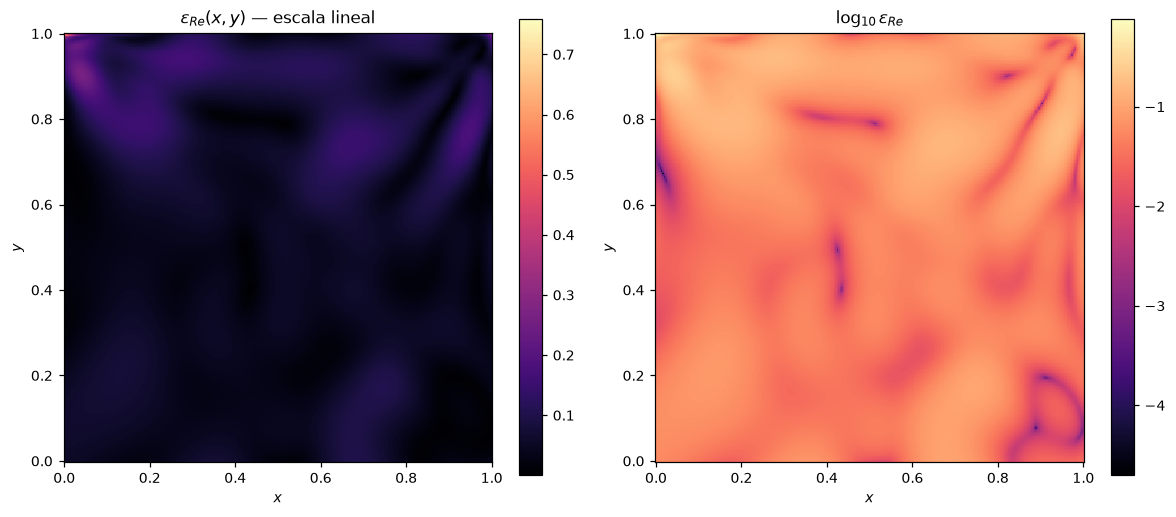

epsilon_Re: min 0.000 | mediana 0.051 | máx 0.759
máximo en (x, y) = (0.000, 1.000)

media de epsilon_Re por estructura física (global = 0.061):
  capa de corte bajo la tapa (y > 0.9)           0.102  (1.66× la media global)
  núcleo del vórtice (r < 0.1 de 0.61, 0.73)     0.105  (1.71× la media global)
  recirculación en esquinas inferiores           0.039  (0.64× la media global)


In [5]:
# Mapa de sensibilidad por diferencias finitas sobre una grilla de 300 x 300
NG = 300
gx = np.linspace(0.0, 1.0, NG)
GX, GY = np.meshgrid(gx, gx)
xf, yf = GX.ravel(), GY.ravel()

u0, v0, _ = predict(fwd[RE_TRUE], xf, yf)
u1, v1, _ = predict(fwd[RE_TRUE + DELTA_RE], xf, yf)

eps_re = np.sqrt((((u1 - u0) / DELTA_RE) / SIGMA_U) ** 2
                 + (((v1 - v0) / DELTA_RE) / SIGMA_V) ** 2).reshape(NG, NG)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, (field, ttl, cmap) in zip(axes, [
    (eps_re, r"$\varepsilon_{Re}(x,y)$ — escala lineal", "magma"),
    (np.log10(eps_re + 1e-12), r"$\log_{10}\varepsilon_{Re}$", "magma"),
]):
    im = ax.pcolormesh(GX, GY, field, cmap=cmap, shading="auto")
    fig.colorbar(im, ax=ax)
    ax.set(title=ttl, xlabel="$x$", ylabel="$y$", aspect="equal")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_sensibilidad.png", bbox_inches="tight")
plt.show()

print(f"epsilon_Re: min {eps_re.min():.3f} | mediana {np.median(eps_re):.3f} | "
      f"máx {eps_re.max():.3f}")
iy, ix = np.unravel_index(eps_re.argmax(), eps_re.shape)
print(f"máximo en (x, y) = ({gx[ix]:.3f}, {gx[iy]:.3f})")
# Nucleo del vortice primario: punto interior de menor magnitud de velocidad en la referencia
inner = (ref["x"] > 0.1) & (ref["x"] < 0.9) & (ref["y"] > 0.1) & (ref["y"] < 0.9)
i_core = np.argmin(np.where(inner, np.hypot(ref["u"], ref["v"]), np.inf))
xc, yc = ref["x"][i_core], ref["y"][i_core]

zones = {
    "capa de corte bajo la tapa (y > 0.9)": GY > 0.9,
    f"núcleo del vórtice (r < 0.1 de {xc:.2f}, {yc:.2f})": np.hypot(GX - xc, GY - yc) < 0.1,
    "recirculación en esquinas inferiores": ((GX < 0.2) | (GX > 0.8)) & (GY < 0.2),
}
print(f"\nmedia de epsilon_Re por estructura física (global = {eps_re.mean():.3f}):")
for name, m in zones.items():
    print(f"  {name:<44} {eps_re[m].mean():7.3f}  "
          f"({eps_re[m].mean() / eps_re.mean():.2f}× la media global)")

> *¿Dónde se concentra la sensibilidad? ¿Coincide con alguna estructura física reconocible del flujo (capa de corte, núcleo del vórtice, zonas de recirculación en las esquinas)?*

La sensibilidad se concentra en el núcleo del vórtice primario (1,71× la media global) y en la capa de corte bajo la tapa (1,66×), es decir donde la viscosidad gobierna el flujo. El núcleo queda en (0,61; 0,73), que coincide con el valor de Ghia et al. para Re = 100. Las recirculaciones de las esquinas inferiores quedan en 0,64×, con el fluido casi estancado.

El máximo global cae en (0; 1), una esquina singular de la tapa, donde la solución exacta no está acotada y el modelo forward tiene su mayor error. Es un artefacto: el mapa por autograd del ítem 4 lo ubica en (0,244; 0,940), dentro de la capa de corte. La Lectura 5.1 advierte justamente sobre esto: calculadas sobre un modelo sin converger, la sensibilidad y la matriz de Fisher quedan dominadas por el error de entrenamiento.

---
# 2. Tres configuraciones de sensores

Ubico una grilla de $N_{\rm data}=9$ puntos ($3\times3$) de $0{,}25\times0{,}25$ en tres posiciones: (a) centrada en la zona de $\varepsilon_{Re}$ promedio máximo, (b) centrada en $\Omega$, (c) centrada en una zona de $\varepsilon_{Re}$ mínimo. Para cada una calculo $\mathcal{I}(Re)=\sum_{i=1}^{9}\varepsilon_{Re}(x_i,y_i)^2$ y las ordeno por identificabilidad esperada, antes de entrenar ningún modelo inverso.

configuración                      centro          I(Re)   orden predicho
----------------------------------------------------------------------------
a) máx. sensibilidad     (0.137, 0.873)         0.3167   1º
b) centro de Ω           (0.500, 0.500)         0.0286   2º
c) mín. sensibilidad     (0.873, 0.127)        0.02322   3º


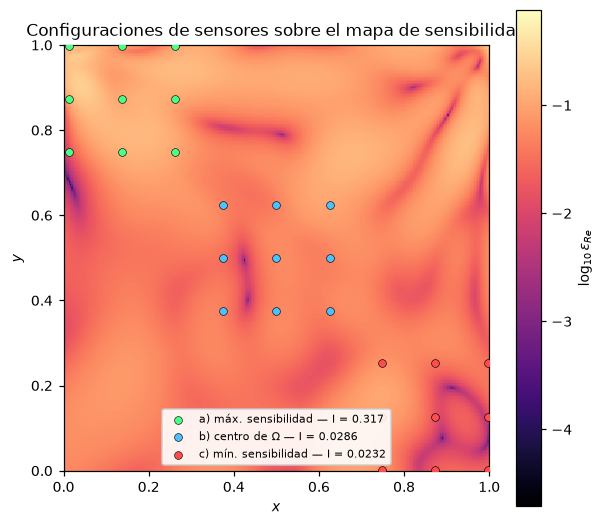

In [6]:
PATCH = 0.25
HALF = PATCH / 2


def sensor_grid(cx, cy):
    """Los 9 puntos de una grilla 3x3 de lado PATCH centrada en (cx, cy)."""
    a = np.array([-HALF, 0.0, HALF])
    gx_, gy_ = np.meshgrid(cx + a, cy + a)
    return np.stack([gx_.ravel(), gy_.ravel()], axis=1)


# Promedio de epsilon_Re en ventanas de 0.25 x 0.25; solo centros con la ventana dentro de Omega
win = int(round(PATCH * (NG - 1)))
mean_map = uniform_filter(eps_re, size=win, mode="constant", cval=0.0)
valid = np.zeros_like(mean_map, dtype=bool)
m0 = int(np.ceil(HALF * (NG - 1)))
valid[m0:NG - m0, m0:NG - m0] = True
masked = np.where(valid, mean_map, np.nan)

iy_max, ix_max = np.unravel_index(np.nanargmax(masked), masked.shape)
iy_min, ix_min = np.unravel_index(np.nanargmin(masked), masked.shape)

configs = {
    "a) máx. sensibilidad": (gx[ix_max], gx[iy_max]),
    "b) centro de Ω": (0.5, 0.5),
    "c) mín. sensibilidad": (gx[ix_min], gx[iy_min]),
}

eps_at = RegularGridInterpolator((gx, gx), eps_re.T)   # eps_re es [iy, ix]
sensors, I_pred = {}, {}
for name, (cx, cy) in configs.items():
    pts = sensor_grid(cx, cy)
    sensors[name] = pts
    I_pred[name] = float(np.sum(eps_at(pts) ** 2))

print(f"{'configuración':<24} {'centro':>16} {'I(Re)':>14}   orden predicho")
print("-" * 76)
for r, (name, val) in enumerate(sorted(I_pred.items(), key=lambda kv: -kv[1]), start=1):
    cx, cy = configs[name]
    print(f"{name:<24} ({cx:.3f}, {cy:.3f}) {val:>14.4g}   {r}º")

fig, ax = plt.subplots(figsize=(5.6, 5))
im = ax.pcolormesh(GX, GY, np.log10(eps_re + 1e-12), cmap="magma", shading="auto")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\varepsilon_{Re}$")
for (name, pts), c in zip(sensors.items(), ("#4CFF88", "#4CC3FF", "#FF4C4C")):
    ax.scatter(pts[:, 0], pts[:, 1], s=26, c=c, edgecolors="k", linewidths=0.4,
               label=f"{name} — I = {I_pred[name]:.3g}", zorder=3)
ax.set(xlabel="$x$", ylabel="$y$", xlim=(0, 1), ylim=(0, 1), aspect="equal",
       title="Configuraciones de sensores sobre el mapa de sensibilidad")
ax.legend(loc="lower center", fontsize=7.5, framealpha=0.9)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_sensores.png", bbox_inches="tight")
plt.show()

$\mathcal{I}(Re)$ es la información de Fisher del diseño (Lectura 5.1: $\mathcal{I}=\sigma^{-2}S^\top S$; el $1/\sigma$ ya está dentro de $\varepsilon_{Re}$). La cota de Cramér-Rao da la precisión mínima alcanzable, $\sigma_{Re}\ge\mathcal{I}(Re)^{-1/2}$:

| Configuración | $\mathcal{I}(Re)$ | $\sigma_{Re}$ mínimo | CV |
|---|---|---|---|
| a) máx. sensibilidad | 0,3167 | 1,78 | 1,8 % |
| b) centro de Ω | 0,0286 | 5,91 | 5,9 % |
| c) mín. sensibilidad | 0,02322 | 6,56 | 6,6 % |

Las tres tienen $\mathcal{I}>0$, así que $Re$ es estructuralmente identificable en cualquiera de los tres diseños. Lo que cambia entre ellos es la precisión.

---
# 3. Entrenamiento inverso

LHS con $N_{\rm pde}=10\,000$ y $N_{\rm bc}=1000$ (igual que el TP2), 25 000 épocas, $\lambda_{\rm bc}=10$, $\lambda_p=100$ y $\lambda_{\rm data}=10$. Los datos rotulados son la solución MEF interpolada en los 9 sensores; la versión con ruido suma $\mathcal{N}(0,\sigma)$ a cada componente. Parametrizo la incógnita como $\nu=1/Re=e^{\theta}$ para mantener $\nu>0$, y arranco en $Re=50$ en las seis corridas.

In [7]:
interp_uv = LinearNDInterpolator(np.stack([ref["x"], ref["y"]], axis=1),
                                 np.stack([ref["u"], ref["v"]], axis=1))
rng_noise = np.random.default_rng(SEED)

sensor_data = {}
for name, pts in sensors.items():
    uv = interp_uv(pts)
    noisy = uv + rng_noise.normal(0.0, [SIGMA_U, SIGMA_V], size=uv.shape)
    for label, vals in (("limpios", uv), ("con ruido", noisy)):
        sensor_data[(name, label)] = (
            torch.tensor(pts, dtype=DTYPE, device=DEVICE),
            torch.tensor(vals, dtype=DTYPE, device=DEVICE),
        )
    print(f"{name:<24} |u| medio {np.abs(uv[:, 0]).mean():.4f} | "
          f"|v| medio {np.abs(uv[:, 1]).mean():.4f}")

a) máx. sensibilidad     |u| medio 0.3234 | |v| medio 0.1099
b) centro de Ω           |u| medio 0.1709 | |v| medio 0.0893
c) mín. sensibilidad     |u| medio 0.0165 | |v| medio 0.0146


In [8]:
def train_inverse(data, tag, seed=SEED):
    """Entrena pesos e incognita conjuntamente. Devuelve el Re estimado y el historial."""
    torch.manual_seed(seed)
    model = PINN(LAYERS).to(DEVICE)
    theta = torch.tensor(np.log(1.0 / RE_INIT), dtype=DTYPE, device=DEVICE, requires_grad=True)
    ds = build_dataset(N_PDE_INV, N_BC_INV, seed=seed, lhs=True)
    hist, dt = train(model, ds, EPOCHS_INV, W_INV, lambda: torch.exp(theta),
                     extra_params=(theta,), data=data, tag=tag)
    re_hat = float(torch.exp(-theta.detach()))
    print(f"{tag}: Re estimado = {re_hat:.3f} | error = {abs(re_hat - RE_TRUE) / RE_TRUE:.2%} "
          f"| {dt / 60:.1f} min")
    return {"re": re_hat, "hist": hist, "t": dt, "model": model}


runs = {}
for name in sensors:
    for label in ("limpios", "con ruido"):
        runs[(name, label)] = train_inverse(sensor_data[(name, label)],
                                            tag=f"{name} — datos {label}")


--- a) máx. sensibilidad — datos limpios | 25,000 épocas ---
   época       total       L_pde        L_bc      L_data        Re     t[s]
       0  9.3511e+02  1.1654e+02  1.7306e+00  4.5923e-01    50.000      3.1
    1000  3.5011e-01  7.0086e-02  1.4518e-02  1.3484e-02    69.114     14.8
    2000  1.8316e-01  3.4912e-02  9.9085e-03  4.9163e-03    91.731     26.6
    3000  1.0710e-01  2.3682e-02  7.1791e-03  1.1629e-03   114.713     38.4
    4000  8.4388e-02  1.5733e-02  6.0343e-03  8.3123e-04   133.825     50.2
    5000  7.0989e-02  1.2357e-02  5.1553e-03  7.0514e-04   158.674     62.1
    6000  6.3661e-02  1.1053e-02  4.6804e-03  5.8038e-04   180.105     74.2
    7000  6.0693e-02  1.0542e-02  4.2191e-03  4.4309e-04   217.600     86.4
    8000  5.6053e-02  8.6988e-03  3.8605e-03  8.7432e-04   270.628     98.6
    9000  4.8219e-02  8.5446e-03  3.4472e-03  3.1712e-04   333.930    110.6
   10000  6.6234e-02  2.5713e-02  3.5145e-03  5.1414e-04   406.605    122.8
   11000  3.8915e-02  6.91

configuración                   I(Re)   Re (limpio)      err   Re (ruido)      err
----------------------------------------------------------------------------------
a) máx. sensibilidad           0.3167      1661.324 1561.32%     1654.761 1554.76%
b) centro de Ω                 0.0286      3079.358 2979.36%     2962.366 2862.37%
c) mín. sensibilidad          0.02322      2555.287 2455.29%     2521.317 2421.32%


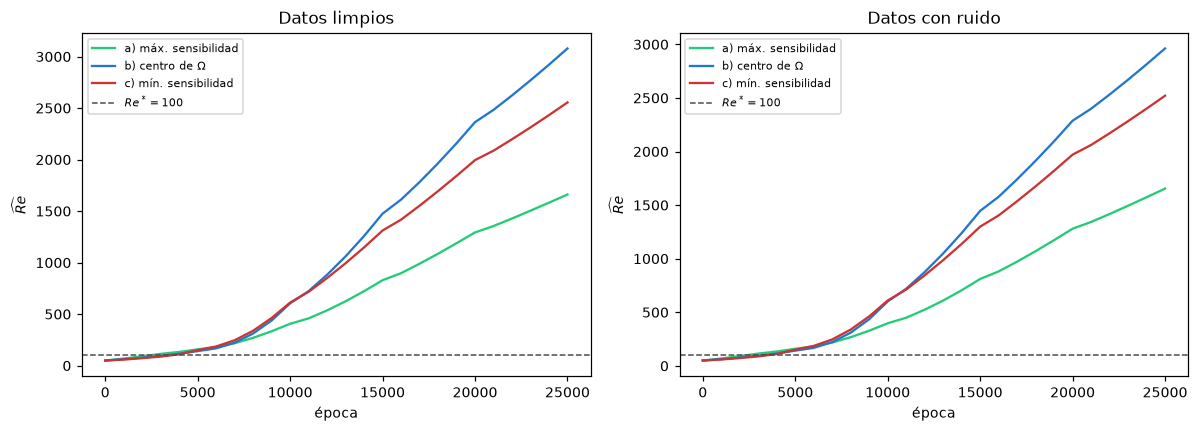

In [9]:
print(f"{'configuración':<24} {'I(Re)':>12} {'Re (limpio)':>13} {'err':>8} "
      f"{'Re (ruido)':>12} {'err':>8}")
print("-" * 82)
for name in sorted(sensors, key=lambda k: -I_pred[k]):
    rc, rn = runs[(name, "limpios")]["re"], runs[(name, "con ruido")]["re"]
    print(f"{name:<24} {I_pred[name]:>12.4g} {rc:>13.3f} "
          f"{abs(rc - RE_TRUE) / RE_TRUE:>7.2%} {rn:>12.3f} "
          f"{abs(rn - RE_TRUE) / RE_TRUE:>7.2%}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, label in zip(axes, ("limpios", "con ruido")):
    for name, c in zip(sensors, ("#2C7", "#27C", "#C33")):
        h = runs[(name, label)]["hist"]
        ax.plot(h["epoch"], h["re"], lw=1.5, c=c, label=name)
    ax.axhline(RE_TRUE, ls="--", lw=1, c="0.3", label="$Re^* = 100$")
    ax.set(title=f"Datos {label}", xlabel="época", ylabel=r"$\widehat{Re}$")
    ax.legend(fontsize=7.5)
fig.tight_layout()
fig.savefig(FIG_DIR / "03_convergencia_re.png", bbox_inches="tight")
plt.show()

> *El orden de precisión predicho en el ítem 2 (usando sólo el mapa de sensibilidad), ¿coincide con el orden obtenido empíricamente en el ítem 3? Si no coincide, ¿a qué lo atribuiría (error de optimización, elección de $\Delta Re$, u otra causa)?*

No coincide: ninguna de las seis corridas identifica $Re$. Las tres divergen y siguen subiendo en la época 25 000, con errores de entre 1555 % y 2979 %. El diseño experimental no es la causa: $\mathcal{I}(Re)>0$ en las tres configuraciones y la cota promete entre 1,8 % y 6,6 %.

Del orden predicho sobrevive que (a) es la que menos diverge (1655 contra 2521 y 2962). (b) y (c) quedan invertidas, pero sus $\mathcal{I}$ difieren apenas 23 %, por debajo de lo que resuelve el mapa por diferencias finitas; por autograd se separan por un factor 26.

La divergencia no viene de $\Delta Re$ ni de $\lambda_{\rm data}$, sino del esquema conjunto. La red no toma $\nu$ como entrada, así que $\partial\mathcal{L}_{\rm data}/\partial\theta=0$ exactamente y la incógnita recibe gradiente sólo de $\mathcal{L}_{\rm pde}$, que baja llevando $\nu\to0$. Con 9 sensores el campo no queda determinado: la red los ajusta a $2{,}6\times10^{-5}$ mientras $\mathcal{L}_{\rm pde}$ sigue empujando. Probé normalizar el *misfit* por $\sigma$, unas $10^4$ veces más fuerte, y la divergencia se acelera en vez de frenarse ($\widehat{Re}=271$ contra 169 a las 6000 épocas); congelar $Re$ 2000 épocas tampoco la evita.

---
# 4. (Opcional) Problema paramétrico

$Re$ pasa a ser la tercera entrada de la red, muestreado $Re\sim\mathcal{U}(50,150)$ en cada punto de colocación durante el entrenamiento físico, sin datos rotulados. Con ese modelo calculo $\varepsilon_{Re}$ por autograd en $Re=100$ e identifico $\widehat{Re}$ sin reentrenar los pesos.

In [10]:
RE_LO, RE_HI = 50.0, 150.0
LAYERS_P = [3] + [64] * 5 + [3]


class ParametricPINN(nn.Module):
    """Red (x, y, Re) -> (u, v, p), con las tres entradas normalizadas a [-1, 1]."""

    def __init__(self, layers=LAYERS_P, activation=nn.Tanh):
        super().__init__()
        mods = []
        for i in range(len(layers) - 1):
            mods.append(nn.Linear(layers[i], layers[i + 1]))
            if i < len(layers) - 2:
                mods.append(activation())
        self.net = nn.Sequential(*mods)
        self.apply(PINN._init_weights)

    def forward(self, xyr):
        xy = 2.0 * xyr[:, 0:2] - 1.0
        re = 2.0 * (xyr[:, 2:3] - RE_LO) / (RE_HI - RE_LO) - 1.0
        return self.net(torch.cat([xy, re], dim=1))


def pde_residuals_param(model, xyr):
    """Residuos del modelo parametrico: derivadas respecto de (x, y), con nu = 1/Re por punto."""
    e_x = torch.zeros_like(xyr); e_x[:, 0] = 1.0
    e_y = torch.zeros_like(xyr); e_y[:, 1] = 1.0
    out, dx, dxx = _nested_jvp(model, xyr, e_x)
    _, dy, dyy = _nested_jvp(model, xyr, e_y)
    nu = 1.0 / xyr[:, 2:3]
    u, v = out[:, 0:1], out[:, 1:2]
    u_x, v_x, p_x = dx[:, 0:1], dx[:, 1:2], dx[:, 2:3]
    u_y, v_y, p_y = dy[:, 0:1], dy[:, 1:2], dy[:, 2:3]
    r_x = u * u_x + v * u_y + p_x - nu * (dxx[:, 0:1] + dyy[:, 0:1])
    r_y = u * v_x + v * v_y + p_y - nu * (dxx[:, 1:2] + dyy[:, 1:2])
    return r_x, r_y, u_x + v_y


def train_parametric(epochs=EPOCHS_INV, seed=SEED):
    """Entrenamiento fisico del modelo parametrico. Re se resortea en cada epoca."""
    torch.manual_seed(seed)
    model = ParametricPINN().to(DEVICE)
    ds = build_dataset(N_PDE_INV, N_BC_INV, seed=seed, lhs=True)
    bc = pack_bc(ds)
    xy_pde, xy_bc = ds["pde"]["xy"], bc["xy"]
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    sched = torch.optim.lr_scheduler.StepLR(opt, step_size=LR_STEP, gamma=LR_GAMMA)
    fn = lambda t: pde_residuals_param(model, t)
    res_fn = torch.compile(fn) if USE_COMPILE else fn
    rand = lambda n: RE_LO + (RE_HI - RE_LO) * torch.rand(n, 1, device=DEVICE)

    print(f"\n--- modelo paramétrico | {epochs:,} épocas ---")
    print(f"{'época':>8} {'total':>11} {'L_pde':>11} {'L_bc':>11} {'t[s]':>8}")
    t0 = time.time()
    for ep in range(epochs):
        r_x, r_y, r_c = res_fn(torch.cat([xy_pde, rand(len(xy_pde))], dim=1))
        L_pde = r_x.pow(2).mean() + r_y.pow(2).mean() + r_c.pow(2).mean()
        out = model(torch.cat([xy_bc, rand(len(xy_bc))], dim=1))
        L_bc = (out[:bc["n_bc"], 0:2] - bc["uv"]).pow(2).mean()
        L_anchor = (out[bc["n_bc"]:, 2:3] - ds["anchor"]["p"]).pow(2).mean()
        total = L_pde + W_INV["bc"] * L_bc + W_INV["anchor"] * L_anchor
        opt.zero_grad(set_to_none=True)
        total.backward()
        opt.step()
        sched.step()
        if ep % LOG_EVERY == 0 or ep == epochs - 1:
            print(f"{ep:>8d} {float(total.detach()):>11.4e} {float(L_pde.detach()):>11.4e} "
                  f"{float(L_bc.detach()):>11.4e} {time.time() - t0:>8.1f}", flush=True)
    return model, time.time() - t0


model_p, t_param = train_parametric()


--- modelo paramétrico | 25,000 épocas ---
   época       total       L_pde        L_bc     t[s]
       0  7.9958e+01  3.8691e+01  1.9372e+00      3.8


/var/folders/bf/p7_3d4ln30l_vsv0f_41b4sw0000gn/T/ipykernel_1937/3137843.py:67: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:823.)
  print(f"{ep:>8d} {float(total):>11.4e} {float(L_pde):>11.4e} "


    1000  3.2682e-01  8.6367e-02  2.3936e-02     15.7
    2000  1.9771e-01  3.9438e-02  1.5771e-02     27.7
    3000  2.5132e-01  8.8667e-02  1.5359e-02     39.5
    4000  1.6845e-01  4.0213e-02  1.2175e-02     51.4
    5000  1.0597e-01  1.3743e-02  8.5653e-03     63.2
    6000  8.6939e-02  1.1522e-02  7.5241e-03     75.0
    7000  8.4998e-02  1.0010e-02  6.6475e-03     86.9
    8000  7.6145e-02  1.3864e-02  6.1333e-03     98.9
    9000  6.1847e-02  8.7835e-03  5.2984e-03    110.9
   10000  5.6799e-02  9.1806e-03  4.7580e-03    122.8
   11000  5.5626e-02  7.9080e-03  4.7418e-03    134.7
   12000  5.4573e-02  1.0481e-02  4.2726e-03    146.5
   13000  4.9745e-02  7.5920e-03  4.2152e-03    158.4
   14000  4.8664e-02  8.6581e-03  3.9940e-03    170.3
   15000  4.5127e-02  7.8424e-03  3.7284e-03    182.2
   16000  4.3165e-02  6.6829e-03  3.6476e-03    194.2
   17000  3.9856e-02  6.3108e-03  3.3459e-03    206.1
   18000  3.7273e-02  5.7774e-03  3.1462e-03    218.1
   19000  3.4632e-02  5.8520

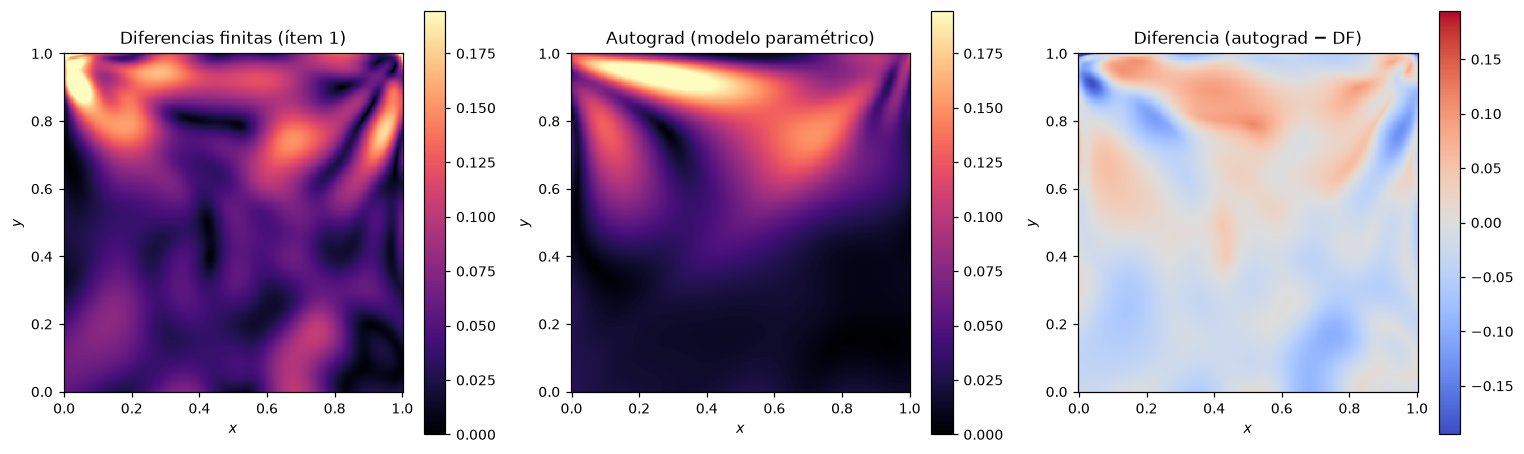

correlación entre ambos mapas: 0.5748
máximo por autograd en (x, y) = (0.244, 0.940)
I(Re) por autograd:
  a) máx. sensibilidad            0.064  (DF: 0.3167)
  b) centro de Ω                0.02935  (DF: 0.0286)
  c) mín. sensibilidad         0.001147  (DF: 0.02322)


In [11]:
# epsilon_Re por autograd directo, evaluado en Re = 100
def eps_re_autograd(model, x, y, re=RE_TRUE, batch=20_000):
    out = []
    for i in range(0, len(x), batch):
        xyr = torch.tensor(np.stack([x[i:i + batch], y[i:i + batch],
                                     np.full(len(x[i:i + batch]), re)], axis=1),
                           dtype=DTYPE, device=DEVICE, requires_grad=True)
        uv = model(xyr)[:, 0:2]
        du = torch.autograd.grad(uv[:, 0].sum(), xyr, retain_graph=True)[0][:, 2]
        dv = torch.autograd.grad(uv[:, 1].sum(), xyr)[0][:, 2]
        out.append(torch.sqrt((du / SIGMA_U) ** 2 + (dv / SIGMA_V) ** 2).detach().cpu().numpy())
    return np.concatenate(out)


eps_auto = eps_re_autograd(model_p, xf, yf).reshape(NG, NG)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
vmax = np.percentile(np.concatenate([eps_re.ravel(), eps_auto.ravel()]), 99)
for ax, (field, ttl) in zip(axes[:2], [(eps_re, "Diferencias finitas (ítem 1)"),
                                       (eps_auto, "Autograd (modelo paramétrico)")]):
    im = ax.pcolormesh(GX, GY, field, cmap="magma", vmin=0, vmax=vmax, shading="auto")
    fig.colorbar(im, ax=ax)
    ax.set(title=ttl, xlabel="$x$", ylabel="$y$", aspect="equal")
im = axes[2].pcolormesh(GX, GY, eps_auto - eps_re, cmap="coolwarm", shading="auto",
                        vmin=-vmax, vmax=vmax)
fig.colorbar(im, ax=axes[2])
axes[2].set(title="Diferencia (autograd − DF)", xlabel="$x$", ylabel="$y$", aspect="equal")
fig.tight_layout()
fig.savefig(FIG_DIR / "04_sensibilidad_autograd.png", bbox_inches="tight")
plt.show()

corr = np.corrcoef(eps_re.ravel(), eps_auto.ravel())[0, 1]
print(f"correlación entre ambos mapas: {corr:.4f}")
print(f"máximo por autograd en (x, y) = "
      f"({gx[np.unravel_index(eps_auto.argmax(), eps_auto.shape)[1]]:.3f}, "
      f"{gx[np.unravel_index(eps_auto.argmax(), eps_auto.shape)[0]]:.3f})")
print(f"I(Re) por autograd:")
eps_auto_at = RegularGridInterpolator((gx, gx), eps_auto.T)
for name, pts in sensors.items():
    print(f"  {name:<24} {float(np.sum(eps_auto_at(pts) ** 2)):>12.4g}  "
          f"(DF: {I_pred[name]:.4g})")

In [12]:
# Identificacion de Re con los pesos congelados: unico parametro libre, el propio Re
best = min(sensors, key=lambda k: abs(runs[(k, "con ruido")]["re"] - RE_TRUE))
print(f"mejor configuración del ítem 3: {best}\n")

for p in model_p.parameters():
    p.requires_grad_(False)

frozen = {}
for label in ("limpios", "con ruido"):
    pts, vals = sensor_data[(best, label)]
    theta = torch.tensor(np.log(RE_INIT), dtype=DTYPE, device=DEVICE, requires_grad=True)
    opt = torch.optim.Adam([theta], lr=1e-2)
    t0 = time.time()
    for ep in range(2_000):
        re = torch.exp(theta)
        out = model_p(torch.cat([pts, re.reshape(1, 1).expand(len(pts), 1)], dim=1))
        loss = (out[:, 0:2] - vals).pow(2).mean()
        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()
    dt = time.time() - t0
    re_hat = float(torch.exp(theta.detach()))
    frozen[label] = {"re": re_hat, "t": dt}
    print(f"datos {label:<10} Re = {re_hat:7.3f} | "
          f"error {abs(re_hat - RE_TRUE) / RE_TRUE:.2%} | {dt:.1f} s")

print(f"\n{'esquema':<38} {'Re (ruido)':>11} {'error':>8} {'tiempo':>10}")
print("-" * 70)
r_joint = runs[(best, "con ruido")]
print(f"{'inverso conjunto (pesos + Re)':<38} {r_joint['re']:>11.3f} "
      f"{abs(r_joint['re'] - RE_TRUE) / RE_TRUE:>7.2%} {r_joint['t'] / 60:>9.1f} m")
print(f"{'paramétrico, pesos congelados':<38} {frozen['con ruido']['re']:>11.3f} "
      f"{abs(frozen['con ruido']['re'] - RE_TRUE) / RE_TRUE:>7.2%} "
      f"{frozen['con ruido']['t']:>9.1f} s")
print(f"{'  (+ entrenamiento paramétrico, único)':<38} {'':>11} {'':>8} "
      f"{t_param / 60:>9.1f} m")

mejor configuración del ítem 3: a) máx. sensibilidad

datos limpios    Re = 105.312 | error 5.31% | 1.3 s
datos con ruido  Re = 108.283 | error 8.28% | 1.3 s

esquema                                 Re (ruido)    error     tiempo
----------------------------------------------------------------------
inverso conjunto (pesos + Re)             1654.761 1554.76%       5.0 m
paramétrico, pesos congelados              108.283   8.28%       1.3 s
  (+ entrenamiento paramétrico, único)                            5.0 m


> *¿Coinciden el mapa por autograd y el de diferencias finitas? ¿Cómo se comparan el resultado y el tiempo de cómputo del esquema de pesos congelados contra el del entrenamiento inverso conjunto?*

Coinciden en la estructura gruesa, no en el detalle (correlación 0,575): ambos ubican la sensibilidad en la mitad superior y ordenan igual las tres configuraciones, pero el de diferencias finitas está moteado y su máximo cae en la esquina singular. El mapa por diferencias finitas es, literalmente, la resta de dos redes entrenadas por separado, con 11 % de error cada una, sobre una señal del orden del 1 %. Por autograd, (b) y (c) se separan por un factor 26 en $\mathcal{I}(Re)$ (0,02935 contra 0,001147), contra 1,2 por diferencias finitas.

Los dos esquemas, con los 9 sensores de la configuración (a), que es la de mayor $\mathcal{I}(Re)$ y también la que menos divergió en el ítem 3:

| Esquema | $\widehat{Re}$ (con ruido) | Error | Tiempo |
|---|---|---|---|
| Inverso conjunto (pesos y $Re$ juntos) | 1655 | 1555 % | 5,0 min |
| Paramétrico, pesos congelados | 108,3 | 8,3 % | 1,3 s |

El paramétrico exige 5 min de entrenamiento previo, que pago una sola vez; después cada identificación son 1,3 segundos. Con datos limpios el error baja a 5,3 %. La cota de Cramér-Rao por autograd para (a) es $\sigma_{Re}\ge3{,}95$ (CV 4,0 %), de modo que los errores obtenidos son 1,3× y 2,1× la cota: por encima, como corresponde a una cota inferior, y en el mismo orden. La brecha es el error de aproximación del modelo paramétrico.